# AdaLux — Training & Evaluation

Questo notebook struttura in un unico flusso riproducibile il **training** e
la **valutazione** di **AdaLux**, l'ambiente Gymnasium custom (`lighting_env.AdaLux`)
che simula il controllo adattivo dell'illuminazione (tapparelle + LED),
organizzato per rispondere a tre domande di ricerca:

- **Q1** — Un agente RL supera un controllore a soglie fisse?
  *Metodo*: training SAC vs baseline a soglie fisse sullo stesso ambiente.
  *Valutazione*: errore medio di lux ed energia consumata su un set di
  episodi di test.
- **Q2** — Quale algoritmo converge meglio ed evita ottimi locali?
  *Metodo*: training PPO e SAC a parità di step.
  *Valutazione*: curve di reward a confronto + osservazione qualitativa del
  comportamento appreso.
- **Q3** — La policy resta affidabile fuori distribuzione (OOD)?
  *Metodo*: test su episodi con condizioni estreme non viste in training.
  *Valutazione*: confronto errore di lux/energia normale vs estremo, più
  osservazione di movimenti bruschi degli attuatori.

Struttura del notebook:

0. Setup
1. Ambiente e funzioni di valutazione comuni
2. Training PPO e SAC (multi-seed, condiviso da Q1 e Q2)
3. **Q1** — SAC vs baseline a soglie fisse
4. **Q2** — PPO vs SAC a parità di step
5. **Q3** — Robustezza fuori distribuzione
6. Conclusioni


## 0. Setup

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

%matplotlib inline

from gymnasium.wrappers import TimeLimit
from stable_baselines3 import PPO, SAC
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy

sys.path.insert(0, os.getcwd())
from lighting_env import AdaLux
from baseline_controller import ThresholdController


class TqdmProgressCallback(BaseCallback):
    '''Barra di avanzamento per model.learn() basata su tqdm.auto invece che
    su model.learn(progress_bar=True) di Stable-Baselines3 (che internamente
    usa tqdm.rich): quest'ultima è nota per "bloccarsi" visivamente in vari
    ambienti Jupyter/VS Code (il training prosegue comunque in background,
    ma la barra non si aggiorna più a schermo). tqdm.auto è più robusta:
    usa un widget ipywidgets se disponibile, altrimenti una barra testuale
    che si aggiorna correttamente riga per riga.'''

    def __init__(self, total_timesteps, desc="Training"):
        super().__init__()
        self.total_timesteps = total_timesteps
        self.desc = desc
        self.pbar = None

    def _on_training_start(self):
        remaining = self.total_timesteps - self.model.num_timesteps
        self.pbar = tqdm(total=max(remaining, 0), desc=self.desc, unit="step")

    def _on_step(self):
        self.pbar.update(self.training_env.num_envs)
        return True

    def _on_training_end(self):
        self.pbar.n = self.pbar.total
        self.pbar.refresh()
        self.pbar.close()

# Le celle di training sotto usano TqdmProgressCallback (progress_bar=False
# passato a model.learn) invece dell'opzione integrata progress_bar=True.
# Le celle di valutazione su più episodi usano tqdm direttamente per lo
# stesso motivo: alcune celle (training SAC, training PPO/SAC di Q2)
# possono richiedere diversi minuti con FAST_MODE = False.

RNG_SEED = 42
np.random.seed(RNG_SEED)

MODELS_DIR = "models"
LOGS_DIR = "logs"
FIG_DIR = "figures"
for d in (MODELS_DIR, LOGS_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

plt.rcParams["figure.dpi"] = 110
print("Setup OK — gymnasium, stable-baselines3, ambiente e baseline caricati.")


Setup OK — gymnasium, stable-baselines3, ambiente e baseline caricati.


In [2]:
# modalità rapida per testing
FAST_MODE = False

# Numero di training seed per PPO eSAC
N_SEEDS = 3

TIMESTEPS = 20_000 if FAST_MODE else 80_000
N_TEST_EPISODES = 10 if FAST_MODE else 30

print(f"FAST_MODE={FAST_MODE} | N_SEEDS={N_SEEDS} | TIMESTEPS={TIMESTEPS} | "
      f"N_TEST_EPISODES={N_TEST_EPISODES}")


FAST_MODE=False | N_SEEDS=3 | TIMESTEPS=80000 | N_TEST_EPISODES=30


In [3]:
DEVICE = "cpu" # è consigliabile usare cpu per via del costo del passaggio dei tensori fra GPU e CPU

cuda_available = torch.cuda.is_available()
effective_device = ("cuda" if cuda_available else "cpu") if DEVICE == "auto" else DEVICE
print(f"DEVICE={DEVICE!r} | GPU (CUDA) disponibile: {cuda_available} | "
      f"device effettivo: {effective_device}")


DEVICE='auto' | GPU (CUDA) disponibile: True | device effettivo: cuda


## 1. Ambiente e funzioni di valutazione comuni

Richiamo rapido dell'ambiente (dettagli completi in `lighting_env.py` /
`README.md`):

- **Episodio** = un giorno simulato, 96 step da 15 minuti.
- **Osservazione** (9 valori normalizzati): ora (sin/cos), lux esterno
  potenziale, lux interno attuale, posizione tapparella, livello LED, lux
  target, stagione, occupazione.
- **Azione** continua `Box(2,)` in `[0,1]`: tapparella e LED, con velocità
  di movimento limitata per step.
- **Reward** (quando occupata): penalità errore di lux, bonus sfruttamento
  luce naturale, penalità abbagliamento, penalità energetica LED, penalità
  di jitter (movimenti bruschi).
- Target di lux, stagione, nuvolosità e occupazione **cambiano ad ogni
  `reset()`**: la policy deve generalizzare, non imparare una routine fissa.

Le funzioni sotto sono condivise dalle tre sezioni Q1/Q2/Q3: eseguono un
episodio con una policy (RL o baseline) e calcolano le metriche di
interesse (errore medio di lux, energia consumata, "jitter" degli
attuatori).


In [4]:
LED_POWER_WATTS = 24.0            # potenza LED a piena potenza (ipotesi di progetto)
ENERGY_PRICE_EUR_PER_KWH = 0.25   # prezzo indicativo energia


def energy_kwh(led_levels, step_minutes=AdaLux.STEP_MINUTES,power_watts=LED_POWER_WATTS):
    # energia consumata dai LED durante l'episodio
    hours_per_step = step_minutes / 60.0
    return float(sum(l * power_watts / 1000.0 * hours_per_step for l in led_levels))


def actuator_jitter(records):
    # calcolo del movimento medio e massimo degli attuatori
    if len(records) < 2:
        return 0.0, 0.0
    deltas = [
        abs(records[i]["blind_pos"] - records[i - 1]["blind_pos"])
        + abs(records[i]["led_level"] - records[i - 1]["led_level"])
        for i in range(1, len(records))
    ]
    return float(np.mean(deltas)), float(np.max(deltas))


def run_episode(policy, seed, env_cls=AdaLux, is_baseline=False):
    # esegue un episodio sia per i modelli che per il controllore a soglie fisse
    env = env_cls(seed=seed)
    obs, _ = env.reset(seed=seed)
    if hasattr(policy, "reset"):
        policy.reset()
    done = False
    records = []
    while not done:
        if is_baseline:
            action, _ = policy.predict(obs, env=env)
        else:
            action, _ = policy.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        info["reward"] = reward
        records.append(info)
        done = terminated or truncated
    return records, env.lux_target, env.season_summer


def episode_metrics(records):
    # calcolo dell'errore medio di lux e di energia in un episodio
    occ = [r for r in records if r["occupied"]]
    mean_lux_err = float(np.mean([r["lux_error"] for r in occ])) if occ else 0.0
    mean_blind_pos_occ = float(np.mean([r["blind_pos"] for r in occ])) if occ else 0.0
    kwh = energy_kwh([r["led_level"] for r in records])
    j_mean, j_max = actuator_jitter(records)
    return {
        "mean_lux_error_pct": mean_lux_err * 100.0,
        "energy_kwh": kwh,
        "jitter_mean": j_mean,
        "jitter_max": j_max,
        "mean_blind_pos_occ": mean_blind_pos_occ,
    }


def evaluate_over_seeds(policy, seeds, env_cls=AdaLux, is_baseline=False,
                         label="policy"):
    # valutazione di una policy su piu episodi di test
    rows = []
    for seed in tqdm(seeds, desc=f"Valutazione {label}", leave=False):
        records, lux_target, season = run_episode(policy, seed, env_cls=env_cls,
                                                    is_baseline=is_baseline)
        m = episode_metrics(records)
        m.update({"seed": seed, "policy": label, "lux_target": lux_target,
                   "season_summer": season})
        rows.append(m)
    return pd.DataFrame(rows)


def plot_day(records, lux_target, season_summer, title_suffix=""):
    # grafico utilizzato per il controllo qualitativo di un episodio
    hours = [r["hour"] for r in records]
    indoor_lux = [r["indoor_lux"] for r in records]
    ext_lux = [r["ext_lux"] for r in records]
    blind = [r["blind_pos"] for r in records]
    led = [r["led_level"] for r in records]
    occ = [r["occupied"] for r in records]

    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

    ax = axes[0]
    ax.plot(hours, indoor_lux, label="Lux interno", color="#d97706", linewidth=2)
    ax.plot(hours, ext_lux, label="Lux esterno (potenziale)", color="#94a3b8",
            linestyle="--", linewidth=1)
    ax.axhline(lux_target, color="#16a34a", linestyle=":", label="Target lux")
    _shade_occupancy(ax, hours, occ)
    ax.set_ylabel("Lux")
    ax.set_title(f"{'Estate' if season_summer else 'Inverno/mezza stagione'} — "
                 f"target {lux_target:.0f} lux {title_suffix}")
    ax.legend(loc="upper right", fontsize=8)

    ax = axes[1]
    ax.plot(hours, blind, label="Tapparella (0=chiusa,1=aperta)", color="#2563eb")
    ax.plot(hours, led, label="LED (0=spento,1=max)", color="#f59e0b")
    _shade_occupancy(ax, hours, occ)
    ax.set_ylabel("Livello [0-1]")
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Ora del giorno")
    ax.legend(loc="upper right", fontsize=8)

    fig.tight_layout()
    return fig


def _shade_occupancy(ax, hours, occ):
    start = None
    for i, o in enumerate(occ):
        if o and start is None:
            start = hours[i]
        if (not o or i == len(occ) - 1) and start is not None:
            end = hours[i]
            ax.axvspan(start, end, color="#22c55e", alpha=0.07)
            start = None


def make_monitored_env(seed, log_dir):
    os.makedirs(log_dir, exist_ok=True)
    env = AdaLux(seed=seed)
    env = TimeLimit(env, max_episode_steps=AdaLux.STEPS_PER_DAY)
    env = Monitor(env, filename=os.path.join(log_dir, "monitor"))
    return env


# Seed dei set di test, NON sovrapposti ai seed usati in training
TEST_SEEDS = list(range(1000, 1000 + N_TEST_EPISODES))
print(f"{len(TEST_SEEDS)} seed di test: {TEST_SEEDS[:5]}...")


30 seed di test predisposti: [1000, 1001, 1002, 1003, 1004]...


## 2. Training PPO e SAC (multi-seed, condiviso da Q1 e Q2)

Alleniamo **PPO** e **SAC** sullo stesso ambiente, per lo stesso numero di
timestep (`TIMESTEPS`) e la stessa architettura di rete (`[128, 128]`),
ripetuto su **`N_SEEDS` training seed indipendenti** (`SEEDS`, impostato
nella cella di configurazione generale, in cima al notebook).

Il motivo per allenare più di un seed: un confronto PPO vs SAC fatto su un
**solo** training run non basta a distinguere un comportamento sistematico
dell'algoritmo su questo ambiente/reward (es. un ottimo locale come
"tapparella sempre chiusa", si veda il `README.md`) da una singola run
andata male per caso.

Questi sono **gli unici modelli allenati in tutto il notebook**: vengono
riusati sia da **Q1** (RL vs baseline: usiamo il SAC del primo seed,
`SEEDS[0]`) sia da **Q2** (PPO vs SAC su tutti i seed) — non alleniamo due
volte lo stesso algoritmo con nomi diversi.

Ogni modello viene salvato singolarmente (`models/ppo_q2_seed{{n}}.zip`,
`models/sac_q2_seed{{n}}.zip`) e ricaricato da disco se già presente
(`RETRAIN = False`, default): non serve riallenare tutto da zero ogni
volta che riapri il notebook, e un'interruzione a metà non fa perdere il
lavoro già fatto.


In [5]:
def train_and_log(algo_name, timesteps, log_dir, seed=RNG_SEED, device=DEVICE,
                   save_path=None, retrain=True):
    #Allena PPO/SAC loggando il reward per episodio con Monitor in log_dir.
    #Se save_path è indicato, il modello addestrato viene salvato su disco
    #(save_path + ".zip"). Se retrain=False e in save_path esiste già un
    #modello salvato, lo carica invece di riallenare da zero — utile per non
    #dover riallenare da zero ogni volta che riapri il notebook.
    algo_cls = {"PPO": PPO, "SAC": SAC}.get(algo_name)
    if algo_cls is None:
        raise ValueError(algo_name)

    if not retrain and save_path is not None and os.path.exists(save_path + ".zip"):
        print(f"Carico {algo_name} già addestrato da {save_path}.zip "
              f"(retrain=False — le curve di reward sotto restano quelle del training precedente)")
        return algo_cls.load(save_path)

    env = make_monitored_env(seed=seed, log_dir=log_dir)
    common_kwargs = dict(verbose=0, seed=seed, device=device, policy_kwargs=dict(net_arch=[128, 128]))
    if algo_name == "PPO":
        model = PPO("MlpPolicy", env, n_steps=256, batch_size=256, n_epochs=10,
                    gamma=0.995, gae_lambda=0.95, learning_rate=3e-4,
                    ent_coef=0.01, clip_range=0.2, **common_kwargs)
    else:  # SAC
        model = SAC("MlpPolicy", env, learning_rate=3e-4, buffer_size=200_000,
                    batch_size=256, gamma=0.995, tau=0.005, train_freq=1,
                    gradient_steps=1, ent_coef="auto", **common_kwargs)

    t0 = time.time()
    model.learn(total_timesteps=timesteps, log_interval=50,
                callback=TqdmProgressCallback(timesteps, desc=algo_name))
    print(f"{algo_name}: training di {timesteps} step completato in {time.time() - t0:.1f}s")
    if save_path is not None:
        model.save(save_path)
        print(f"Modello salvato in {save_path}.zip")
    return model


SEEDS = list(range(1, N_SEEDS + 1))
RETRAIN = False  # True per riallenare da zero anche se i modelli sono gia' stati salvati

models = {}
logs = {}
for seed in tqdm(SEEDS, desc="Training PPO+SAC per seed"):
    for algo_name in ("PPO", "SAC"):
        log_dir = os.path.join(LOGS_DIR, f"q2_{algo_name.lower()}_seed{seed}")
        save_path = os.path.join(MODELS_DIR, f"{algo_name.lower()}_q2_seed{seed}")
        model = train_and_log(algo_name, TIMESTEPS, log_dir, seed=seed,
                               save_path=save_path, retrain=RETRAIN)
        models[(algo_name, seed)] = model
        logs[(algo_name, seed)] = log_dir

print(f"{len(models)} modelli pronti ({len(SEEDS)} seed x 2 algoritmi).")


Training PPO+SAC per seed:   0%|          | 0/3 [00:00<?, ?it/s]

Carico PPO già addestrato da models\ppo_q2_seed1.zip (retrain=False — le curve di reward sotto restano quelle del training precedente)


C:\Users\nicozu\.conda\envs\ML\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Carico SAC già addestrato da models\sac_q2_seed1.zip (retrain=False — le curve di reward sotto restano quelle del training precedente)
Carico PPO già addestrato da models\ppo_q2_seed2.zip (retrain=False — le curve di reward sotto restano quelle del training precedente)
Carico SAC già addestrato da models\sac_q2_seed2.zip (retrain=False — le curve di reward sotto restano quelle del training precedente)
Carico PPO già addestrato da models\ppo_q2_seed3.zip (retrain=False — le curve di reward sotto restano quelle del training precedente)
Carico SAC già addestrato da models\sac_q2_seed3.zip (retrain=False — le curve di reward sotto restano quelle del training precedente)
6 modelli pronti (3 seed x 2 algoritmi).


In [6]:
def smoothed_reward_curve(log_dir, window=10):
    x, y = ts2xy(load_results(log_dir), "timesteps")
    if len(y) >= window:
        y_smooth = pd.Series(y).rolling(window, min_periods=1).mean().values
    else:
        y_smooth = y
    return x, y_smooth


rows = []
for (algo_name, seed), model in tqdm(list(models.items()), desc="Valutazione su TEST_SEEDS"):
    df_ep = evaluate_over_seeds(model, TEST_SEEDS, label=algo_name)
    df_ep["train_seed"] = seed
    rows.append(df_ep)

df_eval = pd.concat(rows, ignore_index=True)  # una riga per (algoritmo, training seed, episodio di test)

# Tabella riassuntiva mostrata PER CIASCUN training seed (non solo la media
# generale): cosi' si vede subito se un comportamento e' coerente seed per
# seed o no, invece di scoprirlo solo in una sezione separata più sotto.
summary_per_seed = df_eval.groupby(["policy", "train_seed"])[
    ["mean_lux_error_pct", "energy_kwh", "mean_blind_pos_occ", "jitter_mean"]
].mean()
summary_per_seed


Valutazione su TEST_SEEDS:   0%|          | 0/6 [00:00<?, ?it/s]

Valutazione PPO:   0%|          | 0/30 [00:00<?, ?it/s]

Valutazione SAC:   0%|          | 0/30 [00:00<?, ?it/s]

Valutazione PPO:   0%|          | 0/30 [00:00<?, ?it/s]

Valutazione SAC:   0%|          | 0/30 [00:00<?, ?it/s]

Valutazione PPO:   0%|          | 0/30 [00:00<?, ?it/s]

Valutazione SAC:   0%|          | 0/30 [00:00<?, ?it/s]

mean_lux_error_pct  energy_kwh  mean_blind_pos_occ  \
policy train_seed                                                       
PPO    1                    32.014650    0.124170            0.020377   
       2                    32.679552    0.150800            0.058579   
       3                    31.783610    0.146159            0.006270   
SAC    1                     4.710461    0.028737            0.321401   
       2                     5.111760    0.024771            0.331653   
       3                     5.643596    0.027501            0.314029   

                   jitter_mean  
policy train_seed               
PPO    1              0.171162  
       2              0.181350  
       3              0.169103  
SAC    1              0.034355  
       2              0.031758  
       3              0.033923

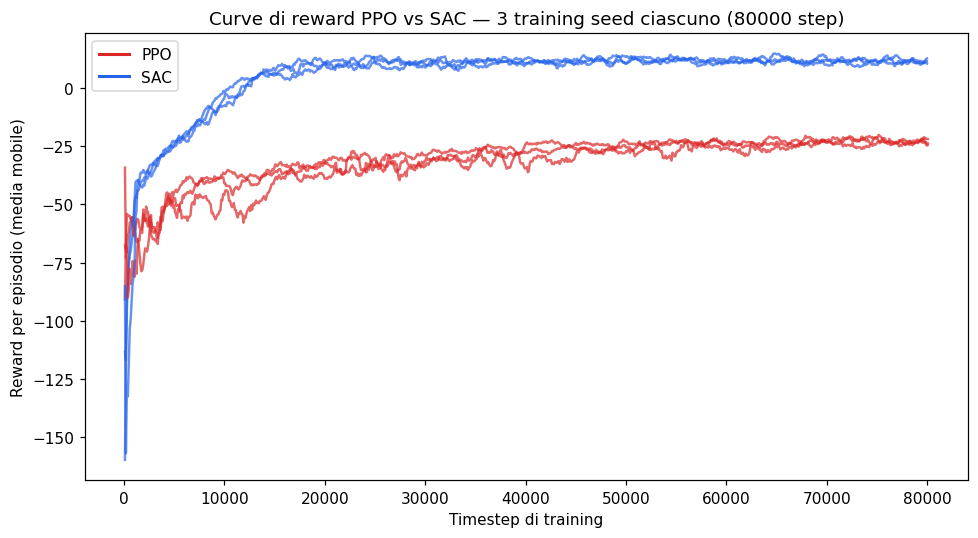

In [7]:
from matplotlib.lines import Line2D

colors_algo = {"PPO": "#dc2626", "SAC": "#2563eb"}

fig, ax = plt.subplots(figsize=(9, 5))
for (algo_name, seed), log_dir in logs.items():
    x, y = smoothed_reward_curve(log_dir)
    ax.plot(x, y, color=colors_algo[algo_name], alpha=0.7, linewidth=1.6)

ax.legend(handles=[Line2D([0], [0], color=c, lw=2, label=a) for a, c in colors_algo.items()])
ax.set_xlabel("Timestep di training")
ax.set_ylabel("Reward per episodio (media mobile)")
ax.set_title(f"Curve di reward PPO vs SAC — {len(SEEDS)} training seed ciascuno ({TIMESTEPS} step)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "reward_curves.png"), dpi=150)
plt.show()


**Come leggere questo grafico**: ogni linea è un training seed
indipendente (stesso colore = stesso algoritmo, `N_SEEDS` linee per
colore). Se le curve dello stesso colore restano vicine tra loro la
convergenza è consistente seed per seed; se sono molto disperse il
risultato dipende fortemente dal seed di training.


## 3. Q1 — Un agente RL supera un controllore a soglie fisse?

**Baseline**: `ThresholdController` (`baseline_controller.py`) — un
controllore a regole fisse rappresentativo di una logica di building
automation tradizionale:

- tarato su un **setpoint nominale fisso** (500 lux) e **non conosce** il
  target reale richiesto nell'episodio (a differenza dell'agente RL, che lo
  osserva);
- tapparella su pochi livelli discreti scelti da soglie di lux assolute;
- LED con controllo bang-bang e banda morta attorno al setpoint nominale.

**Metodo**: confrontiamo la baseline con l'agente **SAC** allenato nella
sezione precedente (seed `SEEDS[0]`, il primo dei modelli condivisi) sullo
stesso set di episodi di test (stessi seed → stesse condizioni
meteo/target/occupazione per entrambi). Non alleniamo un SAC apposta per
Q1: è lo stesso identico modello che compare anche nel confronto
multi-seed di Q2, e la sua valutazione è già stata calcolata sopra
(`df_eval`) — qui la riusiamo senza rivalutarla.

**Valutazione**: errore medio di lux (ore occupate) ed energia consumata
(kWh) sul set di test.


In [8]:
baseline = ThresholdController()
df_baseline = evaluate_over_seeds(baseline, TEST_SEEDS, is_baseline=True, label="Baseline (soglie fisse)")

sac_for_q1 = models[("SAC", SEEDS[0])]
df_sac_q1 = df_eval[(df_eval.policy == "SAC") & (df_eval.train_seed == SEEDS[0])].drop(columns=["train_seed"])

df_q1 = pd.concat([df_baseline, df_sac_q1], ignore_index=True)
summary_q1 = df_q1.groupby("policy")[["mean_lux_error_pct", "energy_kwh"]].agg(["mean", "std"])
summary_q1


Valutazione Baseline (soglie fisse):   0%|          | 0/30 [00:00<?, ?it/s]

mean_lux_error_pct            energy_kwh          
                                      mean        std       mean       std
policy                                                                    
Baseline (soglie fisse)         109.242555  55.083683   0.020020  0.012390
SAC                               4.710461   2.087534   0.028737  0.013311

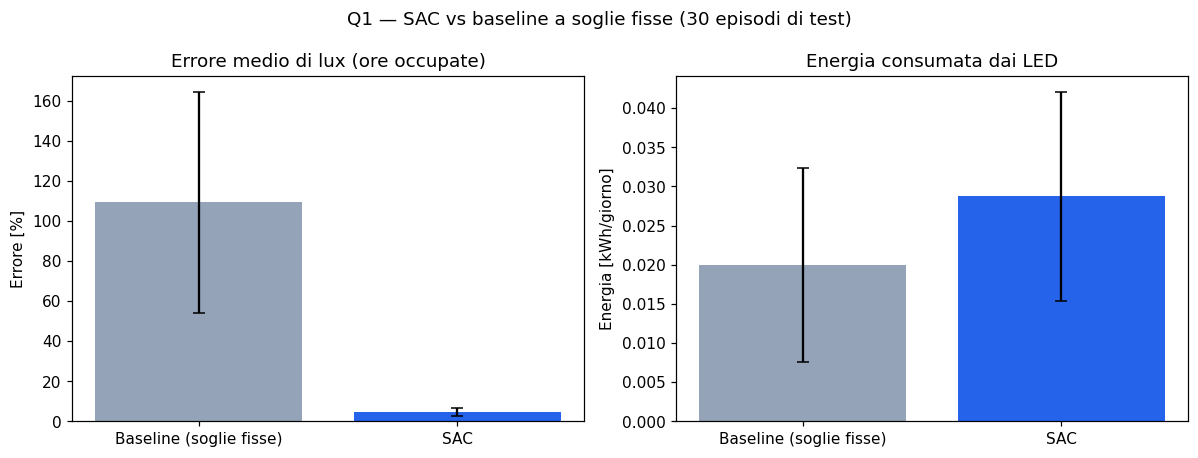

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, col, title, ylabel in [
    (axes[0], "mean_lux_error_pct", "Errore medio di lux (ore occupate)", "Errore [%]"),
    (axes[1], "energy_kwh", "Energia consumata dai LED", "Energia [kWh/giorno]"),
]:
    means = df_q1.groupby("policy")[col].mean()
    stds = df_q1.groupby("policy")[col].std()
    ax.bar(means.index, means.values, yerr=stds.values, capsize=4,
           color=["#94a3b8", "#2563eb"])
    ax.set_title(title)
    ax.set_ylabel(ylabel)

fig.suptitle(f"Q1 — SAC vs baseline a soglie fisse ({len(TEST_SEEDS)} episodi di test)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "q1_sac_vs_baseline.png"), dpi=150)
plt.show()


In [10]:
err_b = df_q1[df_q1.policy.str.contains("Baseline")]["mean_lux_error_pct"].mean()
err_s = df_q1[df_q1.policy == "SAC"]["mean_lux_error_pct"].mean()
kwh_b = df_q1[df_q1.policy.str.contains("Baseline")]["energy_kwh"].mean()
kwh_s = df_q1[df_q1.policy == "SAC"]["energy_kwh"].mean()

print(f"Errore medio di lux — baseline: {err_b:.1f}% | SAC: {err_s:.1f}% "
      f"(riduzione: {(1 - err_s / err_b) * 100:.0f}%)" if err_b > 0 else "")
print(f"Energia media/giorno — baseline: {kwh_b:.3f} kWh | SAC: {kwh_s:.3f} kWh")


Errore medio di lux — baseline: 109.2% | SAC: 4.7% (riduzione: 96%)
Energia media/giorno — baseline: 0.020 kWh | SAC: 0.029 kWh


### Trade-off comfort luminoso vs energia

I due grafici a barre sopra mostrano errore di lux ed energia
**separatamente**: da soli non dicono se SAC riduce l'errore *a scapito* di
più energia, o se domina la baseline su entrambi gli assi
contemporaneamente. Lo scatter e il confronto appaiato sotto mettono le due
grandezze in relazione diretta, episodio per episodio (stesso seed →
stesse condizioni meteo/target/occupazione per baseline e SAC).


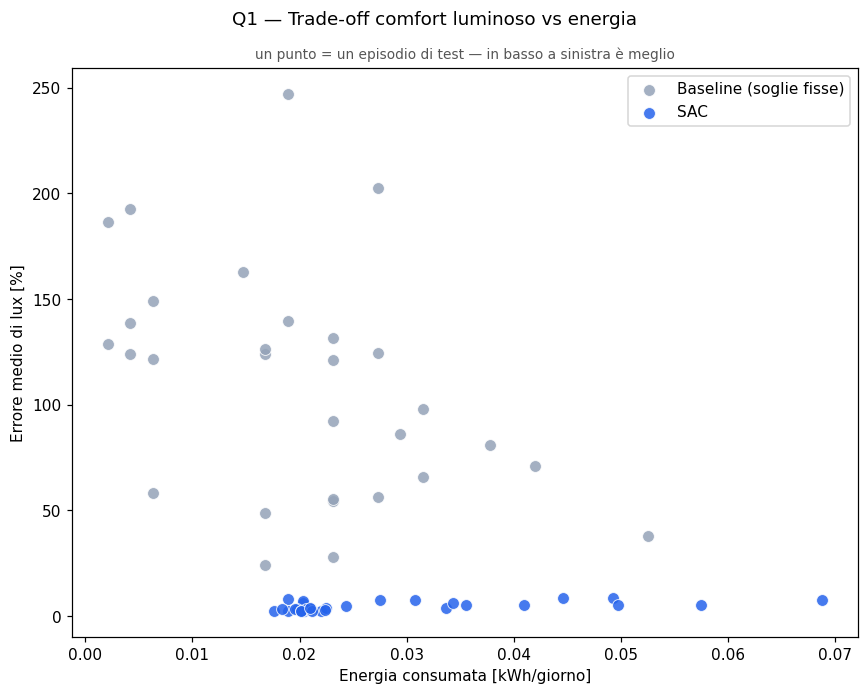

In [11]:
fig, ax = plt.subplots(figsize=(8, 6.4))

colors = {"Baseline (soglie fisse)": "#94a3b8", "SAC": "#2563eb"}
for policy, color in colors.items():
    sub = df_q1[df_q1.policy == policy]
    ax.scatter(sub["energy_kwh"], sub["mean_lux_error_pct"], label=policy,
               color=color, s=60, alpha=0.85, edgecolor="white", linewidth=0.6)

ax.set_xlabel("Energia consumata [kWh/giorno]")
ax.set_ylabel("Errore medio di lux [%]")
fig.suptitle("Q1 — Trade-off comfort luminoso vs energia", fontsize=12, y=0.98)
ax.set_title("un punto = un episodio di test — in basso a sinistra è meglio",
             fontsize=9, color="#555555")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "q1_tradeoff_scatter.png"), dpi=150)
plt.show()


In [12]:
# Confronto appaiato per seed (stesse condizioni per baseline e SAC in ogni
# episodio): su quanti episodi SAC domina la baseline su ENTRAMBI gli assi
# (errore di lux minore E energia minore o uguale, quindi senza alcun
# trade-off sfavorevole), e in quanti invece riduce l'errore ma consuma
# più energia (un vero trade-off comfort/energia).
paired = df_baseline.merge(df_sac_q1, on="seed", suffixes=("_baseline", "_sac"))

dominates = (
    (paired["mean_lux_error_pct_sac"] <= paired["mean_lux_error_pct_baseline"]) &
    (paired["energy_kwh_sac"] <= paired["energy_kwh_baseline"])
)
lower_error_higher_energy = (
    (paired["mean_lux_error_pct_sac"] < paired["mean_lux_error_pct_baseline"]) &
    (paired["energy_kwh_sac"] > paired["energy_kwh_baseline"])
)
delta_energy = paired["energy_kwh_sac"] - paired["energy_kwh_baseline"]
n_total = len(paired)

print(f"SAC domina la baseline (errore minore E energia minore o uguale) in "
      f"{int(dominates.sum())}/{n_total} episodi di test.")
print(f"SAC riduce l'errore ma consuma più energia (vero trade-off) in "
      f"{int(lower_error_higher_energy.sum())}/{n_total} episodi.")
print(f"Delta medio di energia (SAC - baseline): {delta_energy.mean():+.4f} kWh/giorno "
      f"(std: {delta_energy.std():.4f})")


SAC domina la baseline (errore minore E energia minore o uguale) in 7/30 episodi di test.
SAC riduce l'errore ma consuma più energia (vero trade-off) in 23/30 episodi.
Delta medio di energia (SAC - baseline): +0.0087 kWh/giorno (std: 0.0110)


**Come leggere il risultato**: se SAC mostra un errore medio di lux
sensibilmente più basso della baseline (a parità o minor consumo
energetico) sul set di test, la risposta a **Q1** è positiva. Nota che il
vantaggio di SAC qui deriva anche dal fatto che osserva il target reale
dell'episodio (obs. indice 6), mentre la baseline è tarata su un unico
setpoint fisso — è un vantaggio strutturale dell'approccio RL/adattivo, non
solo del training in sé.

Per il trade-off: se la maggioranza degli episodi cade nel quadrante "SAC
domina" (errore minore E energia minore o uguale), il miglioramento di
comfort non ha un costo energetico — è un risultato più forte di un
semplice "in media SAC è migliore su entrambe le metriche", perché regge
episodio per episodio. Se invece emergono episodi con errore minore ma
energia maggiore, quello è un trade-off reale da riportare esplicitamente
(quanti episodi, di quanta energia in più) invece di lasciarlo implicito
nei due grafici a barre separati.

## 4. Q2 — Quale algoritmo converge meglio ed evita ottimi locali?

I modelli PPO e SAC allenati e valutati nella sezione 2, su `N_SEEDS`
training seed indipendenti, sono già pronti: qui li confrontiamo. Per non
finire nella stessa confusione di prima (un seed "primario" con grafici
dettagliati più una sezione a parte per gli altri seed), qui i risultati
si vedono **sempre tutti i seed insieme o seed per seed**, mai un seed
isolato dagli altri.


### Trade-off comfort luminoso vs energia (tutti i seed insieme)

Un punto per episodio di test, per **ogni** training seed — quindi
`N_SEEDS x len(TEST_SEEDS)` punti per algoritmo: un quadro più robusto di
quanto darebbe un singolo training run.


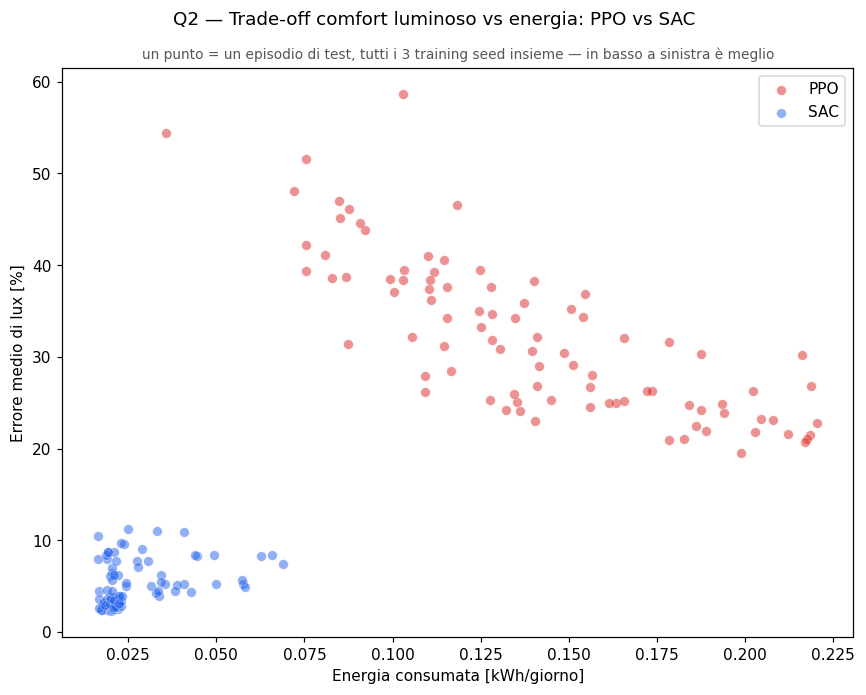

In [13]:
fig, ax = plt.subplots(figsize=(8, 6.4))
for policy, color in colors_algo.items():
    sub = df_eval[df_eval.policy == policy]
    ax.scatter(sub["energy_kwh"], sub["mean_lux_error_pct"], label=policy,
               color=color, s=40, alpha=0.5, edgecolor="white", linewidth=0.4)

ax.set_xlabel("Energia consumata [kWh/giorno]")
ax.set_ylabel("Errore medio di lux [%]")
fig.suptitle("Q2 — Trade-off comfort luminoso vs energia: PPO vs SAC", fontsize=12, y=0.98)
ax.set_title(f"un punto = un episodio di test, tutti i {len(SEEDS)} training seed insieme "
             "— in basso a sinistra è meglio", fontsize=9, color="#555555")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "q2_tradeoff_scatter.png"), dpi=150)
plt.show()


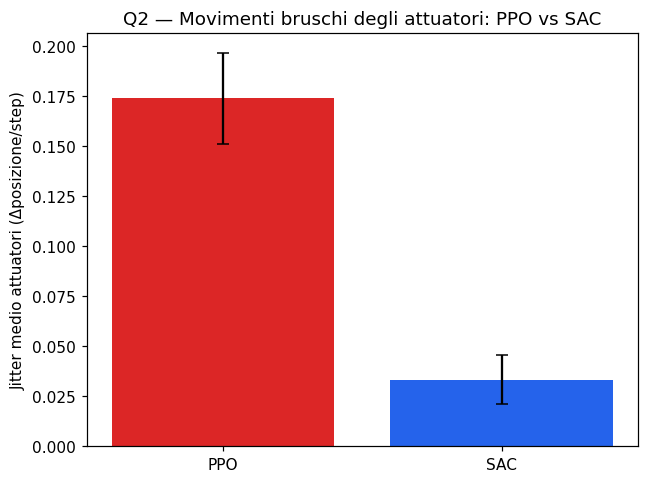

In [14]:
# Jitter degli attuatori (tutti i seed insieme): una policy bloccata su un
# ottimo locale spesso non e' solo "peggiore in media", ma anche meno
# fluida nel controllo (aggiustamenti bruschi e ripetuti).
means = df_eval.groupby("policy")["jitter_mean"].mean()
stds = df_eval.groupby("policy")["jitter_mean"].std()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(means.index, means.values, yerr=stds.values, capsize=4,
       color=[colors_algo[p] for p in means.index])
ax.set_ylabel("Jitter medio attuatori (Δposizione/step)")
ax.set_title("Q2 — Movimenti bruschi degli attuatori: PPO vs SAC")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "q2_jitter.png"), dpi=150)
plt.show()


### È un ottimo locale sistematico o dipende dal seed?

I due grafici sopra pesano ogni episodio allo stesso modo; qui invece un
**punto per training seed** (non per episodio), per capire se un
comportamento è coerente seed per seed — in particolare sull'**uso della
tapparella nelle ore occupate** (`mean_blind_pos_occ`, 0 = sempre chiusa,
1 = sempre aperta): è la metrica più diretta per capire se una policy
sfrutta la luce naturale o collassa su "tapparella chiusa + solo LED",
indipendentemente dal suo errore di lux o energia assoluti.


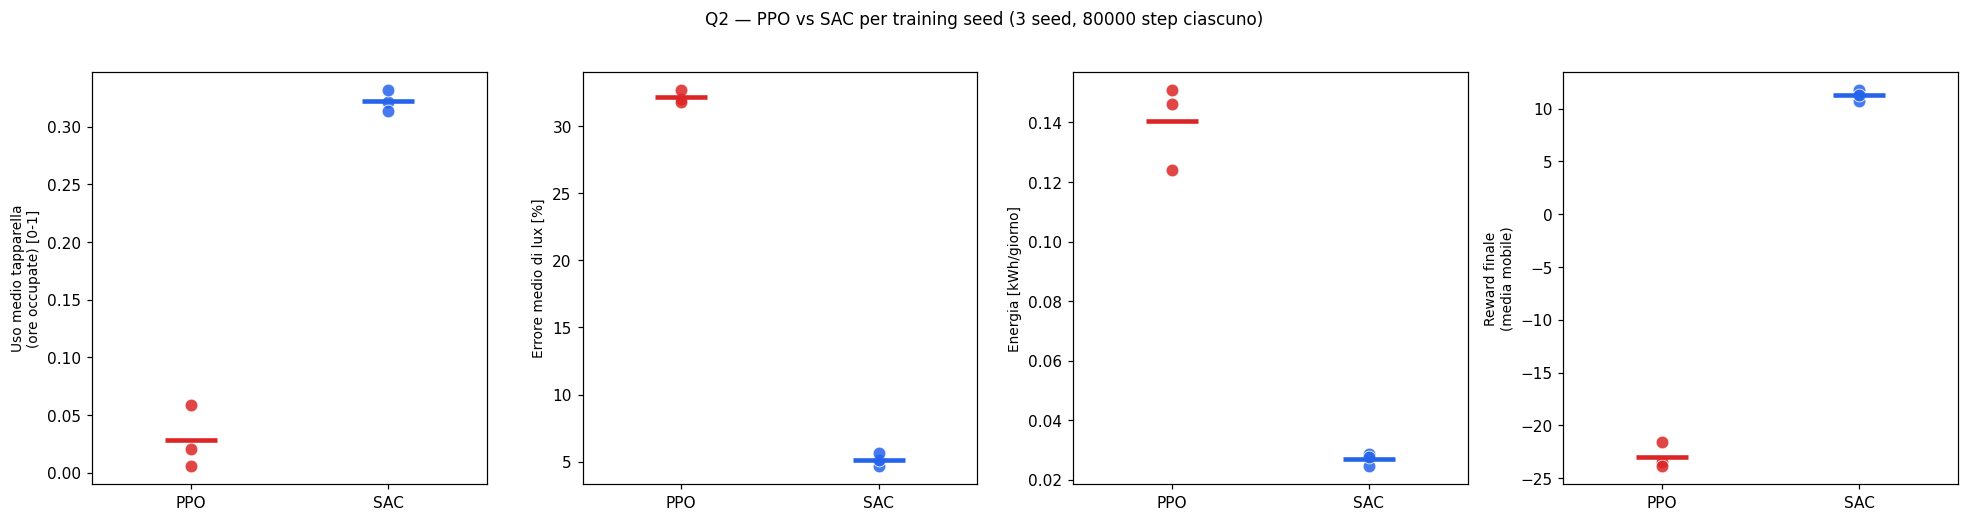

In [15]:
df_per_seed = df_eval.groupby(["policy", "train_seed"]).agg(
    mean_lux_error_pct=("mean_lux_error_pct", "mean"),
    energy_kwh=("energy_kwh", "mean"),
    mean_blind_pos_occ=("mean_blind_pos_occ", "mean"),
).reset_index()

final_rewards = []
for (algo_name, seed), log_dir in logs.items():
    _, final_y = smoothed_reward_curve(log_dir)
    final_rewards.append({
        "policy": algo_name, "train_seed": seed,
        "final_reward": float(np.mean(final_y[-5:])) if len(final_y) else float("nan"),
    })
df_per_seed = df_per_seed.merge(pd.DataFrame(final_rewards), on=["policy", "train_seed"])

metrics_per_seed = [
    ("mean_blind_pos_occ", "Uso medio tapparella\n(ore occupate) [0-1]"),
    ("mean_lux_error_pct", "Errore medio di lux [%]"),
    ("energy_kwh", "Energia [kWh/giorno]"),
    ("final_reward", "Reward finale\n(media mobile)"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
for ax, (col, ylabel) in zip(axes, metrics_per_seed):
    for policy, color in colors_algo.items():
        sub = df_per_seed[df_per_seed.policy == policy]
        ax.scatter([policy] * len(sub), sub[col], color=color, s=70, alpha=0.85,
                   edgecolor="white", linewidth=0.6, zorder=3)
        ax.scatter([policy], [sub[col].mean()], color=color, marker="_", s=1200,
                   linewidth=3, zorder=4)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlim(-0.5, 1.5)

fig.suptitle(f"Q2 — PPO vs SAC per training seed ({len(SEEDS)} seed, {TIMESTEPS} step ciascuno)",
             fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "q2_per_seed_summary.png"), dpi=150, bbox_inches="tight")
plt.show()


**Come leggere il risultato**: ogni pallino è un training seed, il
trattino orizzontale la media su `N_SEEDS` seed. Se i pallini PPO su "uso
medio tapparella" sono tutti vicini a zero (e sistematicamente sotto
quelli SAC su tutti i seed), l'ottimo locale "tapparella chiusa" **non è
un caso isolato**: è un comportamento sistematico di PPO su questo
ambiente/reward. Se invece i risultati PPO sono molto dispersi da seed a
seed, la conclusione "PPO evita/non evita ottimi locali" va sfumata —
dipende dal seed, il tipo di generalizzazione azzardata che la revisione
della proposta segnalava esplicitamente su Q2.


### Osservazione qualitativa: un giorno tipo, per ogni seed

Stesso episodio di test (`TEST_SEEDS[0]` — non serve un seed a parte solo
per questo) per tutti i training seed e per entrambi gli algoritmi, così
il confronto è diretto: se PPO chiude la tapparella in tutti i pannelli e
SAC no, il pattern è robusto al seed di training, non un caso isolato.


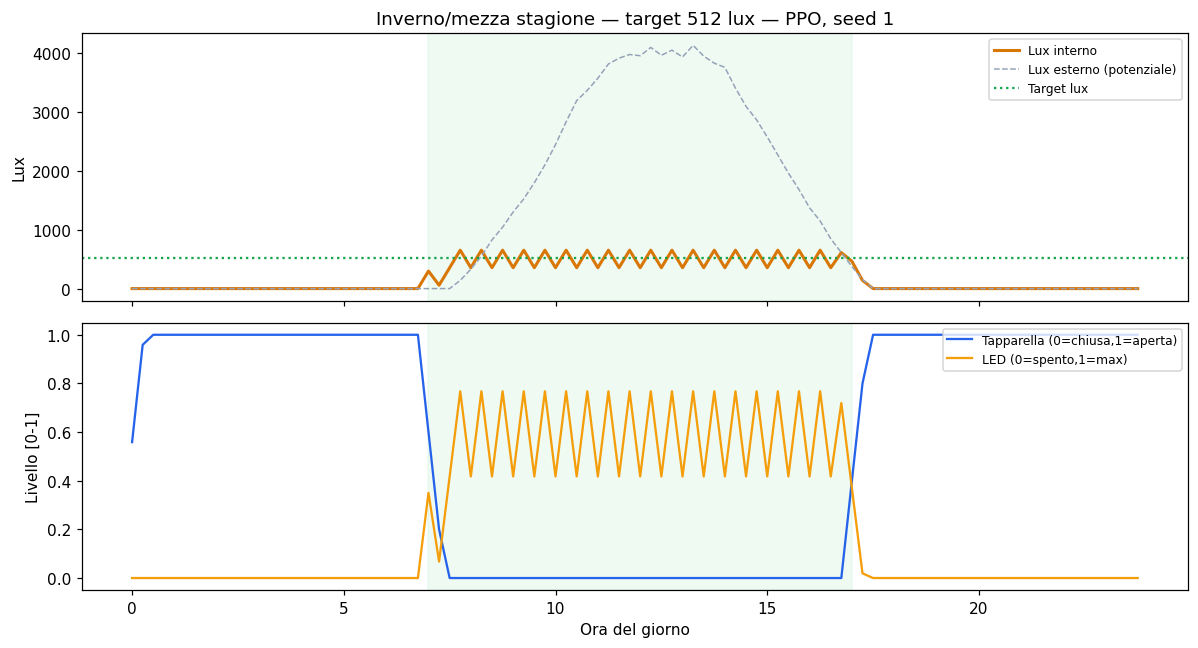

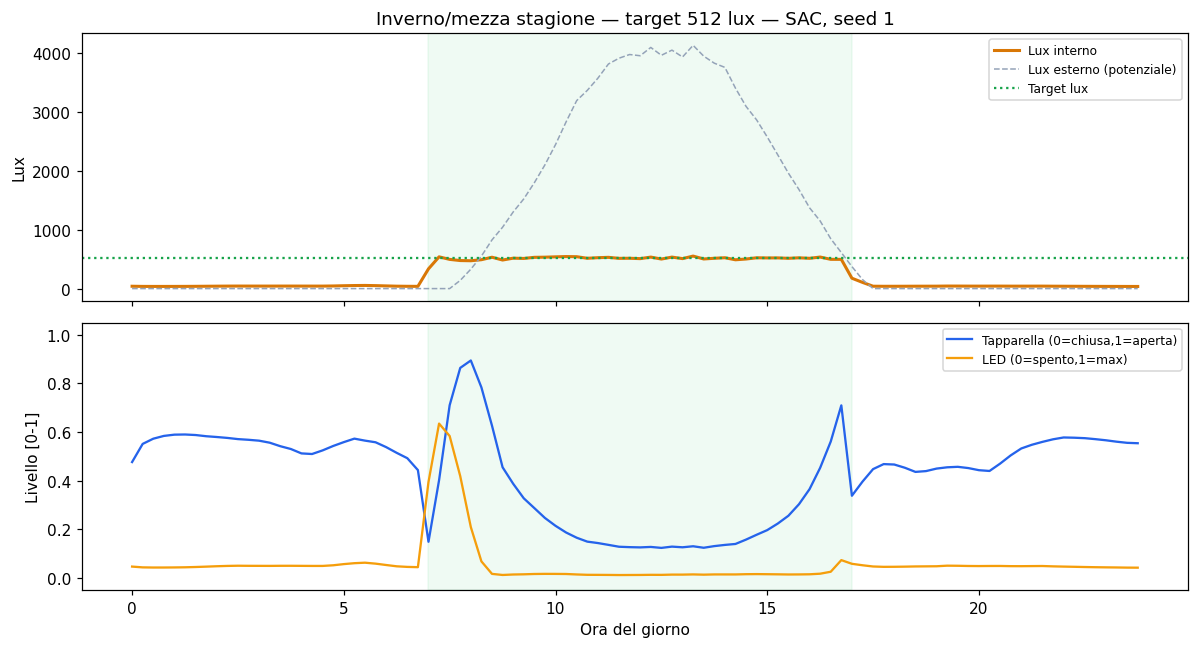

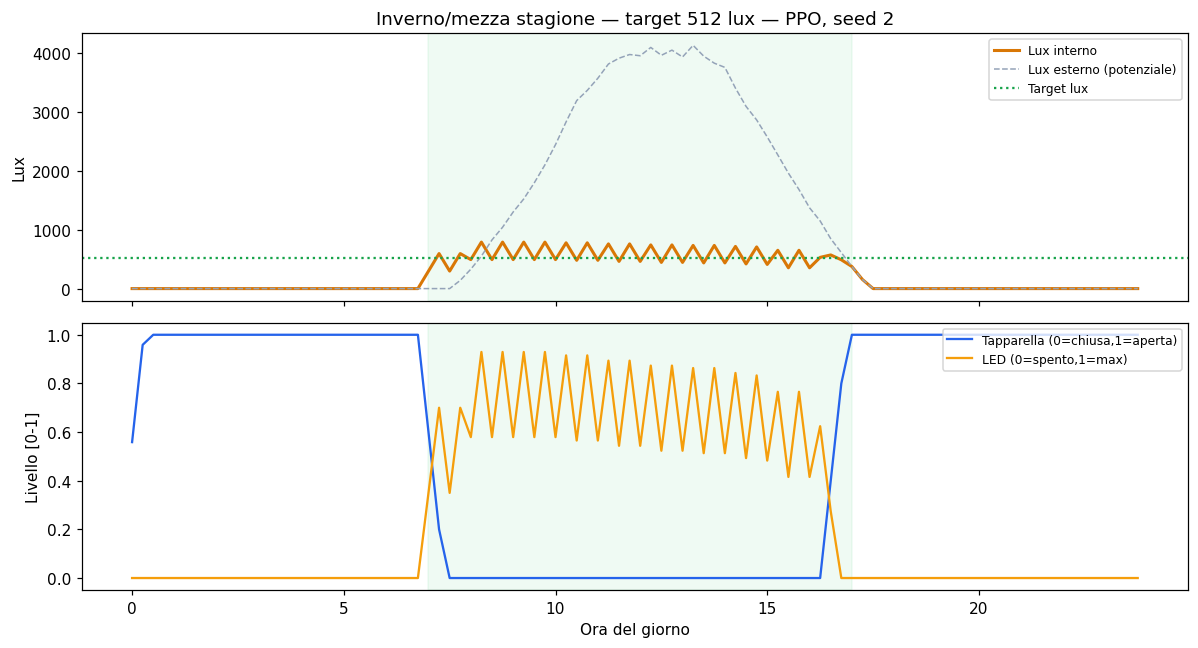

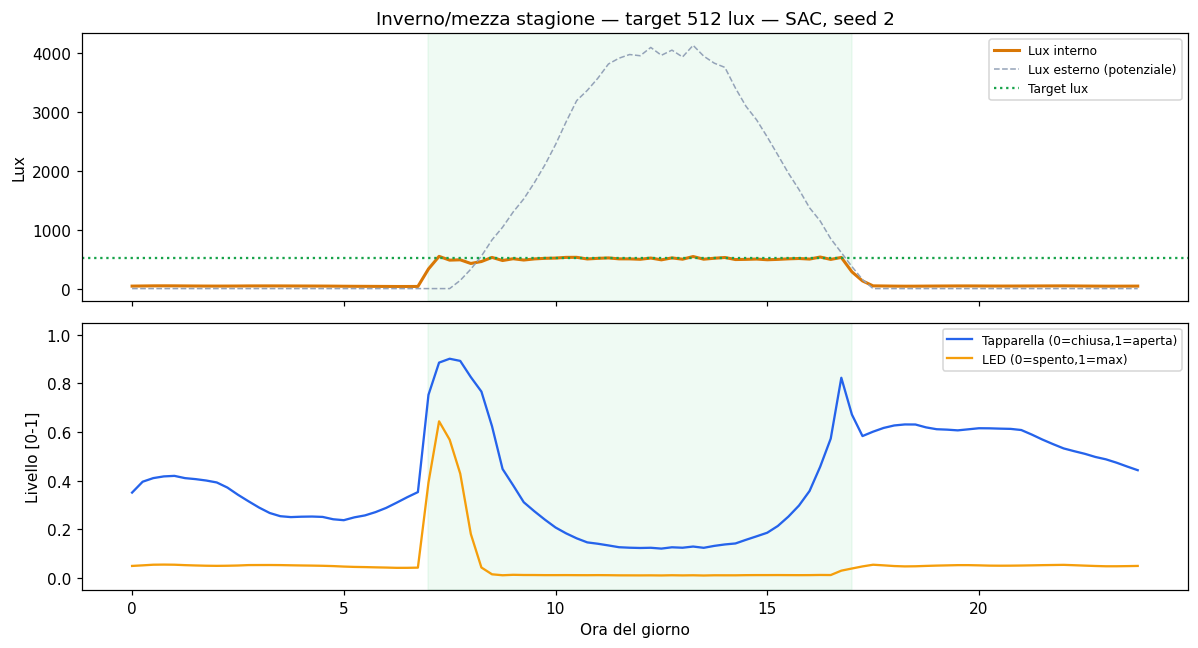

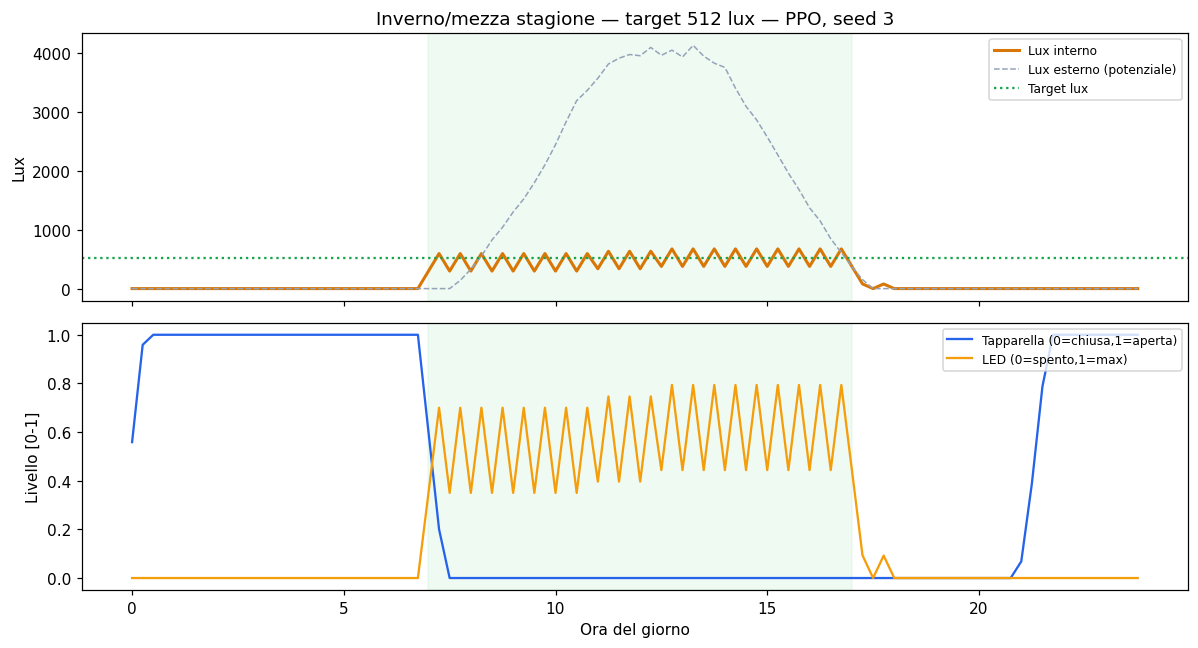

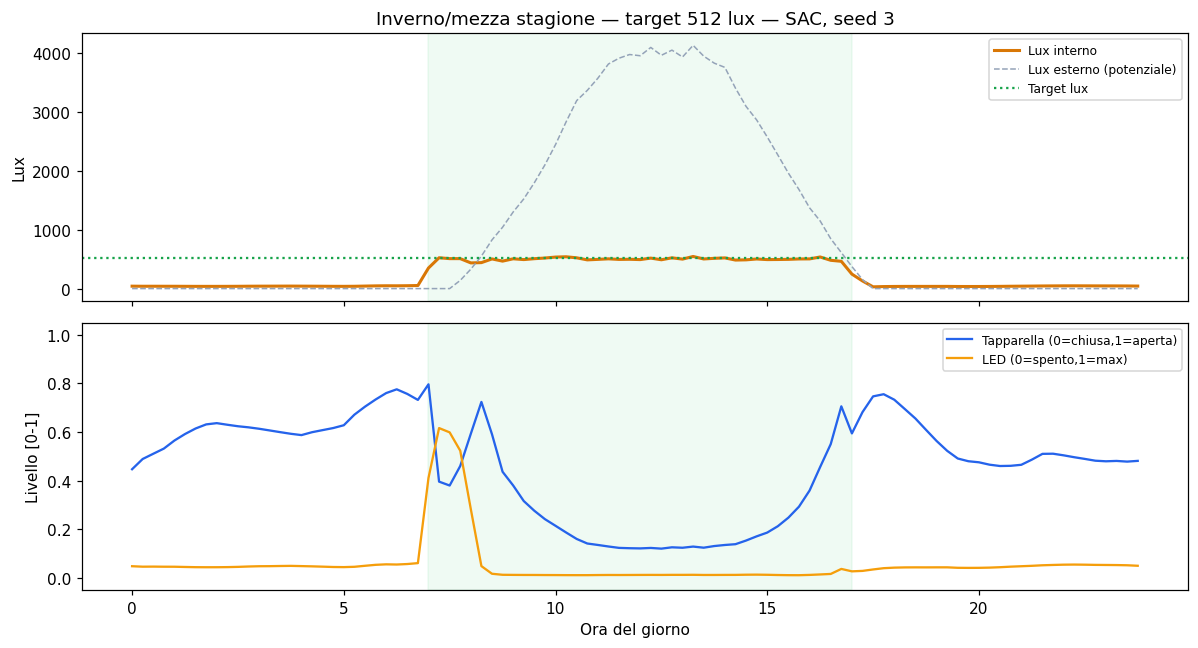

,policy,train_seed,mean_lux_error_pct,energy_kwh,jitter_mean,jitter_max,mean_blind_pos_occ
0,PPO,1,30.670026,0.139666,0.179418,0.750000,0.020000
1,SAC,1,3.896996,0.033667,0.051713,0.644647,0.302215
2,PPO,2,26.739636,0.156042,0.166641,0.750000,0.050000
3,SAC,2,4.219544,0.032916,0.044749,0.750000,0.332716
4,PPO,3,29.057058,0.141553,0.182375,0.750000,0.020000
5,SAC,3,4.447818,0.033599,0.046613,0.605205,0.285678


In [16]:
QUAL_SEED = TEST_SEEDS[0]  # stesso episodio di test usato ovunque nel notebook, nessun seed a parte

day_rows = []
for seed in SEEDS:
    for algo_name in ("PPO", "SAC"):
        model = models[(algo_name, seed)]
        records, target, season = run_episode(model, QUAL_SEED)
        fig = plot_day(records, target, season, title_suffix=f"— {algo_name}, seed {seed}")
        fig.savefig(os.path.join(FIG_DIR, f"q2_{algo_name.lower()}_seed{seed}_day.png"), dpi=150)
        plt.show()
        day_rows.append({"policy": algo_name, "train_seed": seed, **episode_metrics(records)})

pd.DataFrame(day_rows)


**Come leggere il risultato**: se in tutti i pannelli PPO chiude la
tapparella durante le ore occupate e delega tutto ai LED (mentre SAC la
modula), il comportamento è **sistematico**, non un caso isolato di un
singolo seed — è un sintomo di **ottimo locale**: la policy ha imparato
una soluzione "comoda" invece di scoprire che aprire la tapparella riduce
ulteriormente errore ed energia.

## 5. Q3 — La policy resta affidabile fuori distribuzione (OOD)?

**Metodo**: definiamo `ExtremeAdaLux`, una variante
dell'ambiente che genera condizioni **fuori dal range visto in training**:

- target di lux in `[900, 1400]` (il training usa `[300, 750]`);
- nuvolosità quasi sempre agli estremi (foschia densa o cielo sereno
  estremo) con variazioni più rapide e ampie;
- fascia di occupazione molto più ampia (5:00–22:00 contro 7-10/17-20 del
  training).

**Valutazione**: confrontiamo la policy SAC usata anche in Q1
(`sac_for_q1`, seed `SEEDS[0]`) su episodi "normali" vs "estremi" (stessi
seed per le due condizioni), guardando errore di lux, energia e il
**jitter degli attuatori** (movimento medio e massimo per step) come
proxy di movimenti bruschi.


In [17]:
import numpy as np

class ExtremeAdaLux(AdaLux):
    # Variante dell'ambiente con condizioni fuori dal range di training,
    # per testare la generalizzazione OOD della policy (Q3).

    EXTREME_LUX_TARGET_RANGE = (900.0, 1400.0)

    def reset(self, *, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)
        # target di lux ben oltre LUX_TARGET_RANGE visto in training
        self.lux_target = float(self._rng.uniform(*self.EXTREME_LUX_TARGET_RANGE))
        # nuvolosità agli estremi (foschia densa o cielo sereno estremo)
        if self._rng.random() < 0.5:
            self.cloud_factor = float(self._rng.uniform(0.05, 0.15))
        else:
            self.cloud_factor = float(self._rng.uniform(0.95, 1.0))
        # occupazione molto più estesa del range di training
        self.occupancy_start = 5
        self.occupancy_end = 22
        obs = self._build_obs()
        return obs, info

    def _update_cloud_factor(self):
        # random walk più ampio/rapido: meteo instabile, non visto in training
        step = self._rng.normal(0, 0.12)
        self.cloud_factor = float(np.clip(self.cloud_factor + step, 0.02, 1.0))


print("ExtremeAdaLux definito.")


ExtremeAdaLux definito.


In [18]:
df_normal = evaluate_over_seeds(sac_for_q1, TEST_SEEDS, env_cls=AdaLux, label="Normale")
df_extreme = evaluate_over_seeds(sac_for_q1, TEST_SEEDS, env_cls=ExtremeAdaLux, label="Estremo (OOD)")

df_q3 = pd.concat([df_normal, df_extreme], ignore_index=True)
summary_q3 = df_q3.groupby("policy")[["mean_lux_error_pct", "energy_kwh", "jitter_mean", "jitter_max"]].agg(["mean", "std"])
summary_q3


Valutazione Normale:   0%|          | 0/30 [00:00<?, ?it/s]

Valutazione Estremo (OOD):   0%|          | 0/30 [00:00<?, ?it/s]

mean_lux_error_pct           energy_kwh           jitter_mean  \
                            mean       std       mean       std        mean   
policy                                                                        
Estremo (OOD)          36.637672  6.580031   0.166073  0.051599    0.104144   
Normale                 4.710461  2.087534   0.028737  0.013311    0.034355   

                        jitter_max            
                    std       mean       std  
policy                                        
Estremo (OOD)  0.026973   0.666478  0.039900  
Normale        0.015012   0.390289  0.166546

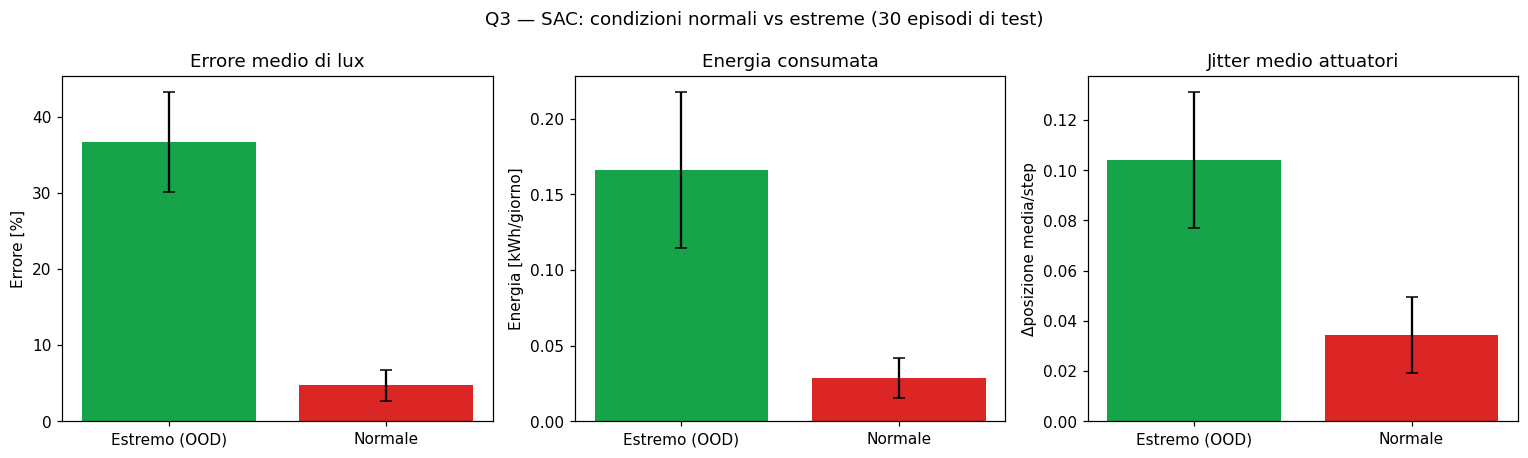

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

panels = [
    ("mean_lux_error_pct", "Errore medio di lux", "Errore [%]"),
    ("energy_kwh", "Energia consumata", "Energia [kWh/giorno]"),
    ("jitter_mean", "Jitter medio attuatori", "Δposizione media/step"),
]
colors = ["#16a34a", "#dc2626"]
for ax, (col, title, ylabel) in zip(axes, panels):
    means = df_q3.groupby("policy")[col].mean()
    stds = df_q3.groupby("policy")[col].std()
    ax.bar(means.index, means.values, yerr=stds.values, capsize=4, color=colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel)

fig.suptitle(f"Q3 — SAC: condizioni normali vs estreme ({len(TEST_SEEDS)} episodi di test)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "q3_normal_vs_extreme.png"), dpi=150)
plt.show()


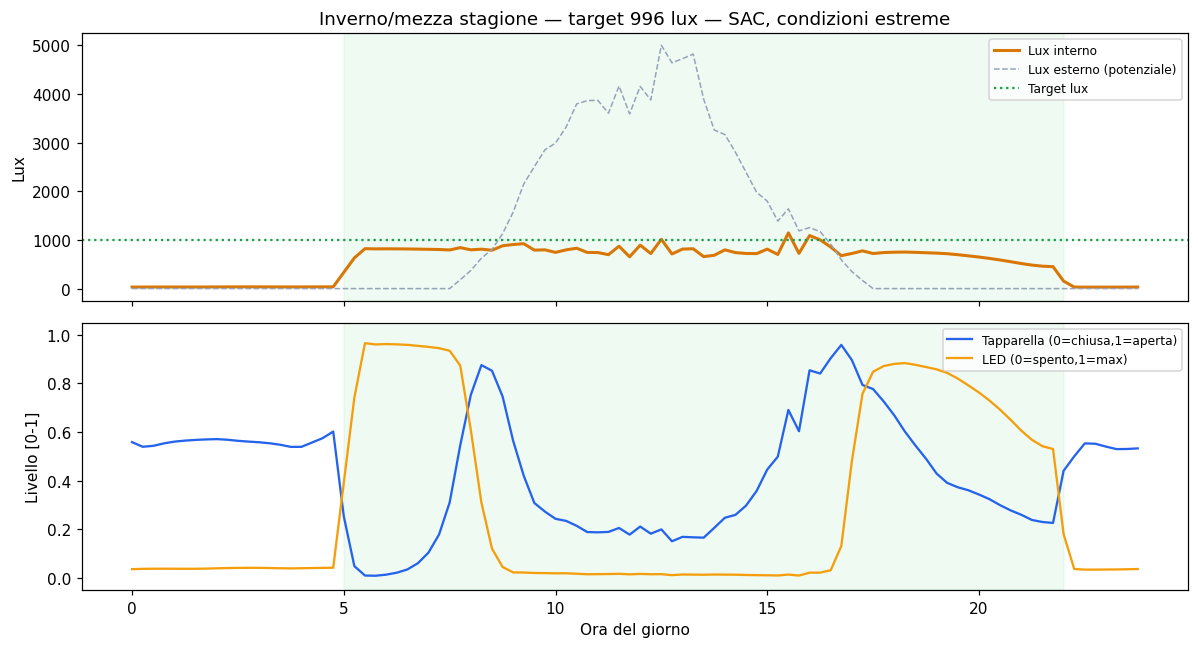

{'mean_lux_error_pct': 25.091846728322402,
 'energy_kwh': 0.17049648367166523,
 'jitter_mean': 0.08637477674950622,
 'jitter_max': 0.6988418757915497,
 'mean_blind_pos_occ': 0.3778923272210009}

In [20]:
# Ispezione qualitativa di un singolo episodio estremo: si notano movimenti
# bruschi/oscillazioni degli attuatori o saturazione delle azioni?
records_extreme, target_extreme, season_extreme = run_episode(sac_for_q1, QUAL_SEED, env_cls=ExtremeAdaLux)
fig_extreme = plot_day(records_extreme, target_extreme, season_extreme, title_suffix="— SAC, condizioni estreme")
fig_extreme.savefig(os.path.join(FIG_DIR, "q3_extreme_day.png"), dpi=150)
plt.show()

episode_metrics(records_extreme)


**Come leggere il risultato**: un aumento marcato dell'errore medio di
lux e/o del jitter nelle condizioni estreme rispetto a quelle normali
indica che la policy **non generalizza bene fuori distribuzione** — atteso,
dato che né il target né la nuvolosità/occupazione estremi rientrano nel
range visto in training. Il grafico qualitativo aiuta a capire *come*
fallisce: saturazione delle azioni (tapparella/LED sempre a 0 o 1),
oscillazioni continue, o errore di lux persistente senza reazione.

## 6. Conclusioni

Riepilogo automatico dei risultati calcolati sopra (da rileggere/commentare
dopo un run con `FAST_MODE = False`, per risultati non "smoke-test").


In [21]:
print("=== Q1 — SAC vs baseline a soglie fisse ===")
print(summary_q1)
print()
print(f"=== Q2 — PPO vs SAC per training seed ({len(SEEDS)} seed, {TIMESTEPS} step ciascuno) ===")
print(df_per_seed.groupby("policy")[["mean_lux_error_pct", "energy_kwh", "mean_blind_pos_occ", "final_reward"]]
      .agg(["mean", "std"]))
print()
print("=== Q3 — SAC: normale vs estremo ===")
print(summary_q3)


=== Q1 — SAC vs baseline a soglie fisse ===
                        mean_lux_error_pct            energy_kwh          
                                      mean        std       mean       std
policy                                                                    
Baseline (soglie fisse)         109.242555  55.083683   0.020020  0.012390
SAC                               4.710461   2.087534   0.028737  0.013311

=== Q2 — PPO vs SAC per training seed (3 seed, 80000 step ciascuno) ===
       mean_lux_error_pct           energy_kwh           mean_blind_pos_occ  \
                     mean       std       mean       std               mean   
policy                                                                        
PPO             32.159270  0.465150   0.140376  0.014225           0.028409   
SAC              5.155273  0.468087   0.027003  0.002029           0.322361   

                 final_reward            
             std         mean       std  
policy                      

Da completare con l'interpretazione dei risultati numerici e grafici
ottenuti eseguendo il notebook con `FAST_MODE = False`:

- **Q1**: l'agente RL supera il controllore a soglie fisse? Di quanto, su
  errore di lux ed energia?
- **Q2**: quale algoritmo converge più velocemente/più in alto? Ci sono
  segnali di ottimo locale (es. tapparella inutilizzata) in uno dei due?
  È coerente su tutti i training seed, o dipende dal seed?
- **Q3**: quanto si degrada la policy fuori distribuzione? I movimenti
  degli attuatori restano ragionevoli o diventano bruschi/instabili?
